# Step 3: MSM construction and validation

In [13]:
%load_ext autoreload
%autoreload 2 

data_folder = "../data/"

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import LogLocator
import plotting_utils as pu
from matplotlib.patches import Patch
from matplotlib import color_sequences
from matplotlib.colors import TwoSlopeNorm

#import networkx as nx # graph visualization of MSM microstates and macrostates model

from pca_wrapper import *
from deeptime.decomposition import TICA
from tqdm.notebook import tqdm  # progress bar 
from deeptime.clustering import KMeans

from deeptime.markov import TransitionCountEstimator
from deeptime.markov.msm import MaximumLikelihoodMSM

from deeptime.util.validation import ck_test
from deeptime.plots import plot_ck_test, Network

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---
#### Reloading reduced data

In [14]:
tica_lag = 100 # lag time for TICA in frames, 1000 frames = 200 nanoseconds
tica_dim_distances = 5
tica_dim_dihedrals = 7
pca_dim_distances = 5
pca_dim_dihedrals = 7


tica_dihedrals = np.load(f"../intermediate_outputs/dimred/tica_lag_{tica_lag}_dim_{tica_dim_dihedrals}_dihedrals.npy")
pca_dihedrals = np.load(f"../intermediate_outputs/dimred/pca_dim_{pca_dim_dihedrals}_dihedrals.npy")
tica_distances = np.load(f"../intermediate_outputs/dimred/tica_lag_{tica_lag}_dim_{tica_dim_distances}_distances.npy")
pca_distances = np.load(f"../intermediate_outputs/dimred/pca_dim_{pca_dim_distances}_distances.npy")


trajectories = [tica_distances, pca_distances, tica_dihedrals, pca_dihedrals]
trajectories_labels = ["tica_distances", "pca_distances", "tica_dihedrals", "pca_dihedrals"]


total_time_micros = 300
time_step_micros =  total_time_micros / 1526041 #/ distances.shape[0]
time_step_nanos = time_step_micros * 10**3
print("Time step (microseconds)", time_step_micros) # 2x10^-4 microseconds
print("Time step (nanoseconds)", time_step_micros * 10**3) # 0.2 nanoseconds
print("Time step (picoseconds)", time_step_micros * 10**6) # 200 picoseconds
one_microsecond_in_frames = int(1 / time_step_micros)
print("One microsecond in frames", one_microsecond_in_frames) # 5000 frames

Time step (microseconds) 0.00019658711659778472
Time step (nanoseconds) 0.19658711659778472
Time step (picoseconds) 196.58711659778473
One microsecond in frames 5086


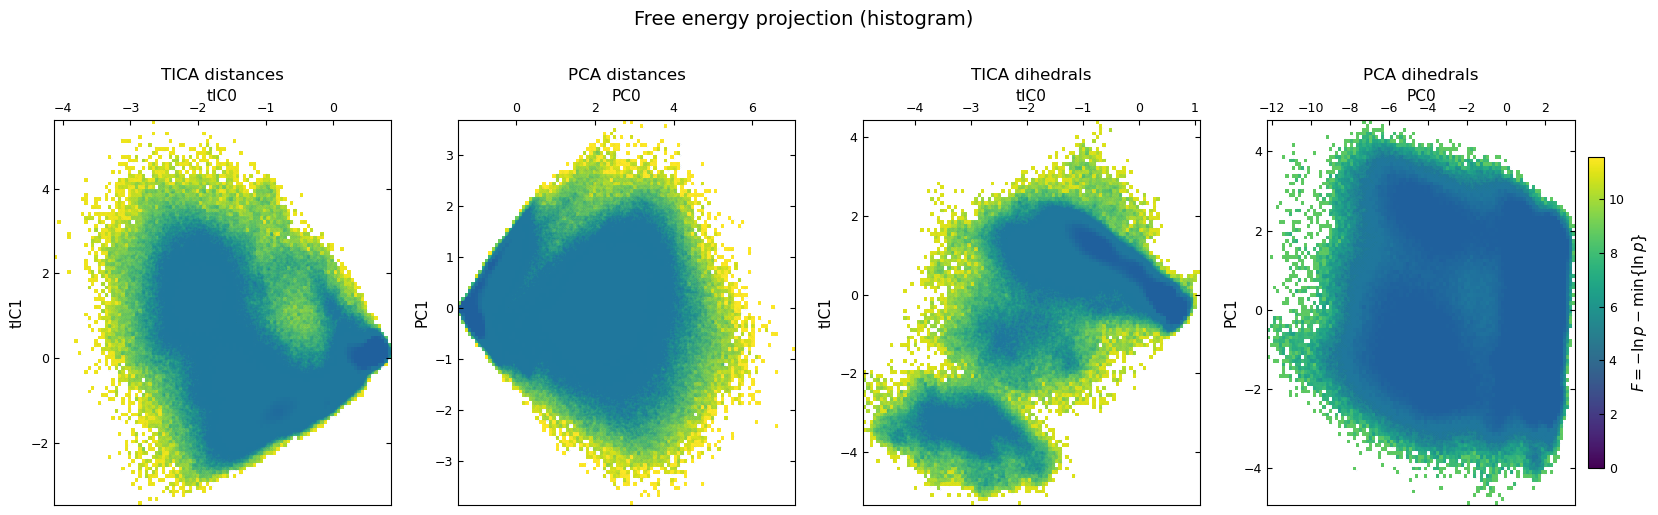

In [15]:
# ---------------------------------------------------------------------------
# First pass: compute all FESs to get global limits for the colorbar
nbins_linear = 100 #np.sqrt(1526041).astype(int) # heuristic for number of bins in 2D histogram, linear scale



Fs = []


component_x = 0
component_y = 1
for traj in trajectories:
    H, xedges, yedges = np.histogram2d(
        traj[:, component_x],
        traj[:, component_y],
        bins=nbins_linear,
        density=True
    )
    mask = H > 0
    F = np.full_like(H, np.nan)
    F[mask] = -np.log(H[mask])
    F -= np.nanmin(F)
    Fs.append(F)


vmin = 0
vmax = np.nanmax([np.nanmax(F) for F in Fs])
# ------------------------------------------------------------------------


fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes = axes.flatten()
pu.plot_free_energy_projection(tica_distances, 0, 1, ax = axes[0], nbins_linear=nbins_linear, vmin = vmin, vmax=vmax, axlabel = "tIC", axtitle = "TICA distances")
pu.plot_free_energy_projection(pca_distances, 0, 1, ax = axes[1], nbins_linear=nbins_linear, vmin = vmin, vmax=vmax, axlabel = "PC", axtitle = "PCA distances")
pu.plot_free_energy_projection(tica_dihedrals, 0, 1, ax = axes[2], nbins_linear=nbins_linear, vmin = vmin, vmax=vmax, axlabel = "tIC", axtitle = "TICA dihedrals")
axes[3], im = pu.plot_free_energy_projection(pca_dihedrals, 0, 1, ax = axes[3], nbins_linear=nbins_linear, vmin = vmin, vmax=vmax, axlabel = "PC", axtitle = "PCA dihedrals")
plt.colorbar(im, ax=axes[3], label=r"$F = -\ln{p} - \min\{{\ln{p}}\}$", fraction=0.046, pad=0.04)

plt.suptitle(f"Free energy projection (histogram)", y = 1.1)
plt.show()

#### Iso-contour maps

this takes approx. 3 minutes to run

In [16]:
from scipy.stats import gaussian_kde

# ---------------------------------------------------------------------------
# KDE-based FES function - slow but accurate
# ---------------------------------------------------------------------------

def compute_fes_kde(traj, component_x=0, component_y=1, nbins=100):
    """
    Compute the free energy surface (FES) using kernel density estimation (KDE).
    """
    x = traj[:, component_x]
    y = traj[:, component_y]

    xmin, xmax = np.nanmin(x), np.nanmax(x)
    ymin, ymax = np.nanmin(y), np.nanmax(y)

    xx, yy = np.meshgrid(
        np.linspace(xmin, xmax, nbins),
        np.linspace(ymin, ymax, nbins)
    )

    values = np.vstack([x, y])
    grid = np.vstack([xx.ravel(), yy.ravel()])

    kde = gaussian_kde(values)
    p = kde(grid).reshape(xx.shape)

    F = -np.log(p)
    F -= np.nanmin(F)

    return xx, yy, F


import numpy as np
from scipy.ndimage import gaussian_filter

# ---------------------------------------------------------------------------
# Fast histogram-based smoothed FES
# ---------------------------------------------------------------------------
def compute_fes_fast(
    traj,
    component_x=0,
    component_y=1,
    nbins=100,
    sigma=1.2,
    padding=0.02,
    eps=1e-12
):
    """
    Fast approximation to a KDE free-energy surface.

    Uses a 2D histogram followed by Gaussian smoothing.
    This is much faster than scipy.stats.gaussian_kde for large trajectories.

    Parameters
    ----------
    traj : ndarray, shape (n_frames, n_features)
        Input trajectory/projection.
    component_x, component_y : int
        Components to project onto.
    nbins : int
        Number of bins along each axis.
    sigma : float
        Gaussian smoothing width in bins.
        Larger values give smoother contours.
    padding : float
        Fractional padding added to x/y limits.
    eps : float
        Small floor to avoid log(0).

    Returns
    -------
    xx, yy : ndarray
        Meshgrid of bin centers.
    F : ndarray
        Free energy surface, shifted so min(F)=0.
    """

    x = traj[:, component_x]
    y = traj[:, component_y]

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    xmin, xmax = np.min(x), np.max(x)
    ymin, ymax = np.min(y), np.max(y)

    dx = xmax - xmin
    dy = ymax - ymin

    xmin -= padding * dx
    xmax += padding * dx
    ymin -= padding * dy
    ymax += padding * dy

    H, xedges, yedges = np.histogram2d(
        x,
        y,
        bins=nbins,
        range=[[xmin, xmax], [ymin, ymax]],
        density=True
    )

    # Smooth the density estimate
    H_smooth = gaussian_filter(H, sigma=sigma)

    # Avoid log(0)
    H_smooth = np.maximum(H_smooth, eps)

    F = -np.log(H_smooth)
    F -= np.nanmin(F)

    # Bin centers
    xcenters = 0.5 * (xedges[:-1] + xedges[1:])
    ycenters = 0.5 * (yedges[:-1] + yedges[1:])

    xx, yy = np.meshgrid(xcenters, ycenters, indexing="ij")

    return xx, yy, F

In [17]:
nbins_linear = 100

trajectories = [
    tica_distances,
    pca_distances,
    tica_dihedrals,
    pca_dihedrals
]

Fs = []
grids = []

component_x = 0
component_y = 1

for i, traj in enumerate(trajectories):
    print(f"Computing FES for trajectory {trajectories_labels[i]}...")
    xx, yy, F = compute_fes_fast(
        traj,
        component_x=component_x,
        component_y=component_y,
        nbins=nbins_linear
    )
    grids.append((xx, yy))
    Fs.append(F)


Computing FES for trajectory tica_distances...
Computing FES for trajectory pca_distances...
Computing FES for trajectory tica_dihedrals...
Computing FES for trajectory pca_dihedrals...


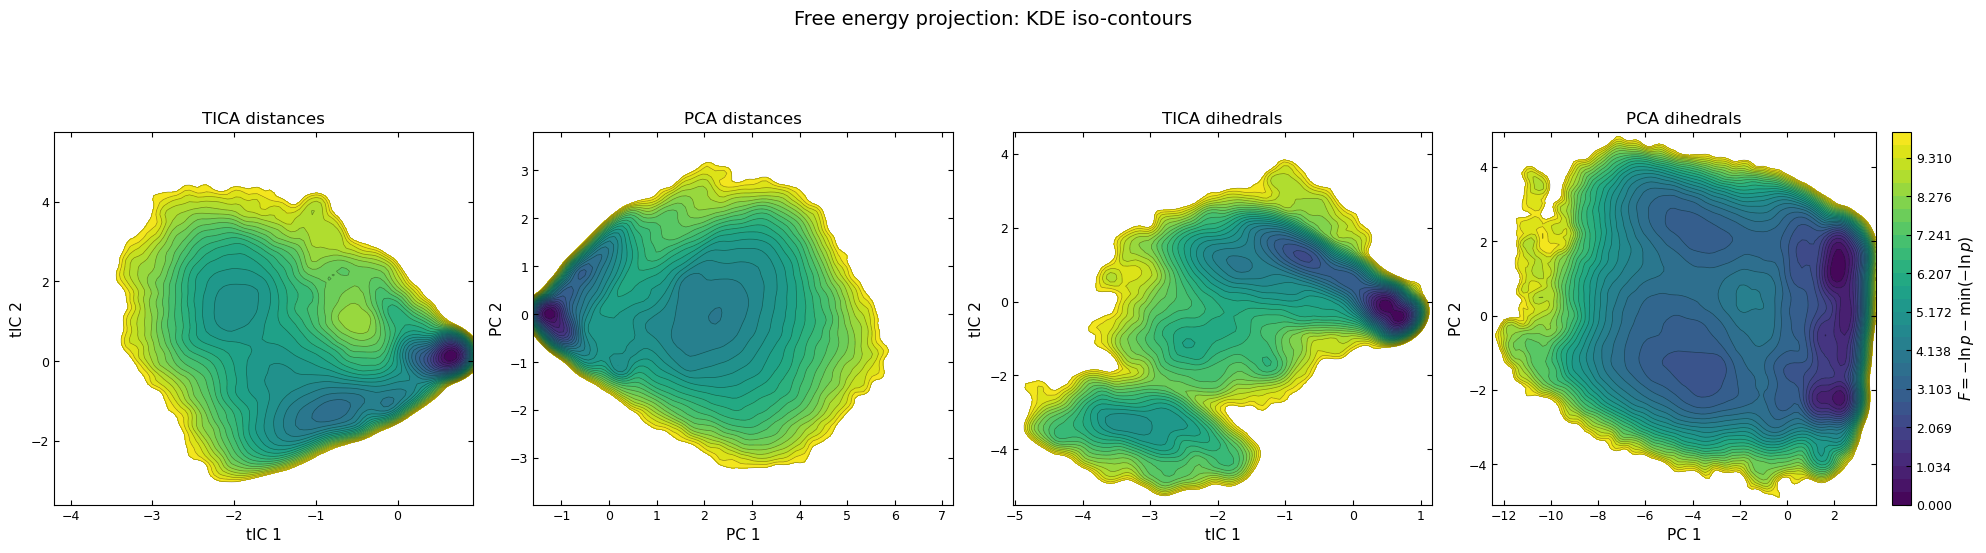

In [ ]:
# ---------------------------------------------------------------------------
# Plot iso-contour FESs

vmin = 0
vmax = 10

levels = np.linspace(vmin, vmax, 30)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes = axes.flatten()

titles = [
    "TICA distances",
    "PCA distances",
    "TICA dihedrals",
    "PCA dihedrals"
]

xlabels = [
    "tIC 1",
    "PC 1",
    "tIC 1",
    "PC 1"
]

ylabels = [
    "tIC 2",
    "PC 2",
    "tIC 2",
    "PC 2"
]

for ax, title, xlabel, ylabel, F, (xx, yy) in zip(
    axes, titles, xlabels, ylabels, Fs, grids
):
    im = ax.contourf(
        xx,
        yy,
        F,
        levels=levels,
        vmin=vmin,
        vmax=vmax
    )

    ax.contour(
        xx,
        yy,
        F,
        levels=levels,
        linewidths=0.5,
        colors="k",
        alpha=0.4
    )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

plt.colorbar(
    im,
    ax=axes[3],
    label=r"$F = -\ln p - \min(-\ln p)$",
    fraction=0.046,
    pad=0.04
)

plt.suptitle("Free energy projection: KDE iso-contours", y=1.1)
#plt.savefig("output_figures/free_energy_projection.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

Even nicer graph

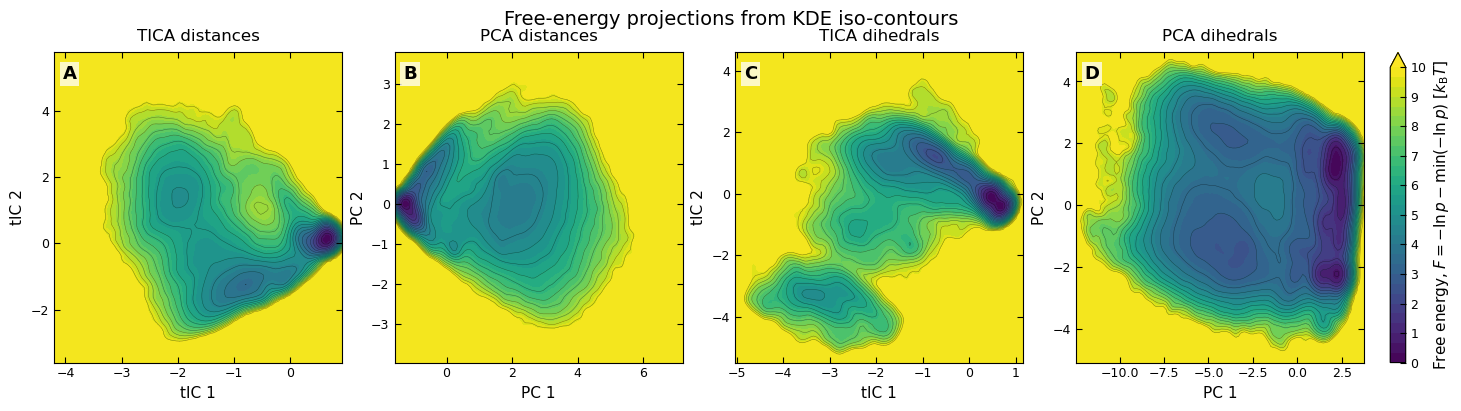

In [20]:
import os
import matplotlib as mpl

# ---------------------------------------------------------------------------
# Report-quality iso-contour FES plot

os.makedirs("output_figures", exist_ok=True)

# Free energy range
vmin = 0
vmax = 10

# Filled-contour and line-contour levels
levels_filled = np.linspace(vmin, vmax, 31)
levels_lines = np.arange(vmin, vmax + 0.5, 0.5)

# Matplotlib publication settings
mpl.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.titlesize": 14,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

titles = [
    "TICA distances",
    "PCA distances",
    "TICA dihedrals",
    "PCA dihedrals"
]

xlabels = [
    "tIC 1",
    "PC 1",
    "tIC 1",
    "PC 1"
]

ylabels = [
    "tIC 2",
    "PC 2",
    "tIC 2",
    "PC 2"
]

panel_labels = ["A", "B", "C", "D"]

# ---------------------------------------------------------------------------
# Figure

fig, axes = plt.subplots(
    1, 4,
    figsize=(14.5, 3.8),
    constrained_layout=True
)

axes = axes.flatten()

cmap = "viridis"

for ax, title, xlabel, ylabel, F, (xx, yy), panel in zip(
    axes, titles, xlabels, ylabels, Fs, grids, panel_labels
):
    # Clip high free energies so all panels share the same visual scale
    F_plot = np.clip(F, vmin, vmax)

    im = ax.contourf(
        xx,
        yy,
        F_plot,
        levels=levels_filled,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        extend="max"
    )

    ax.contour(
        xx,
        yy,
        F_plot,
        levels=levels_lines,
        colors="k",
        linewidths=0.35,
        alpha=0.45
    )

    ax.set_title(title, pad=8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # Panel label
    ax.text(
        0.03,
        0.96,
        panel,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=13,
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
            pad=2.0
        )
    )

    # Better axis appearance
    ax.tick_params(length=4, width=0.8)
    ax.set_aspect("auto")

# Shared colorbar
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="vertical",
    fraction=0.025,
    pad=0.02
)

cbar.set_label(r"Free energy, $F = -\ln p - \min(-\ln p)$ [$k_\mathrm{B}T$]")
cbar.set_ticks(np.arange(vmin, vmax + 1, 1))
cbar.ax.tick_params(length=4, width=0.8)

fig.suptitle(
    "Free-energy projections from KDE iso-contours",
    y=1.04
)

# ---------------------------------------------------------------------------
# Save both raster and vector versions

fig.savefig(
    "output_figures/free_energy_projection_report.png",
    dpi=600,
    bbox_inches="tight"
)

fig.savefig(
    "output_figures/free_energy_projection_report.pdf",
    bbox_inches="tight"
)

plt.show()

---
### performing kmeans clustering + msm transition matrix estimation + implied timescales test

In [21]:
kcluster_list = [100, 200, 500]

run_kmeans = False # avoid rerunning accidentantly as it takes a long time

if run_kmeans:

    for n_clusters in kcluster_list:
        print(f"Running KMeans with {n_clusters} clusters...")
        kmeans = KMeans(
            n_clusters=n_clusters,
            init_strategy='kmeans++',
            max_iter=100,
            fixed_seed=13,
            n_jobs=8,
            progress=tqdm
        )
        #for i, traj in enumerate(trajectories):
        for i, traj in enumerate([tica_dihedrals]):
            #traj_name = trajectories_labels[i]
            traj_name = "tica_dihedrals"
            kmeans.fit(traj)
            discretized_trajectories = kmeans.transform(traj)
            model = kmeans.fetch_model() # fetches the latest model, containing all important information
            plt.loglog(model.inertias)
            plt.xlabel("iteration")
            plt.ylabel("inertia")
            plt.title("KMeans with uniform initialization inertia during training")

            np.savez(f"../intermediate_outputs/kmeans_plusplus/{n_clusters}clusters_{traj_name}", traj = discretized_trajectories, centers = model.cluster_centers)

In [23]:
"""
n_clu_for_plot = 100

feature_names = ["distances", "dihedrals"]
fig, axes = plt.subplots(1, 4, figsize=(15, 3))
axes = axes.flatten()
for i, (traj_name) in enumerate(trajectories_labels):
        data = np.load(f"../intermediate_outputs/kmeans/{n_clu_for_plot}clusters_{traj_name}.npz")
        centers = data["centers"]
        method = traj_name.split("_")[0]
        dtraj = np.load(f"../intermediate_outputs/dimred/{traj_name}.npy")
        if i == len(trajectories_labels) - 1:
                axes[-1], im = pu.plot_free_energy_projection(dtraj, 0, 1, ax = axes[-1], vmin = vmin, vmax=vmax, axlabel = f"{method}", axtitle = f"{traj_name}")
                plt.colorbar(im, ax=axes[-1])
        else:
                pu.plot_free_energy_projection(dtraj, 0, 1, ax = axes[i], vmin = vmin, vmax=vmax, axlabel = f"{method}", axtitle = f"{traj_name}")
        axes[i].scatter(centers[:, 0], centers[:, 1], s=0.4, alpha=1, color = "white",  label = traj_name)

plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.show()


# Plot assignments

fig, axes = plt.subplots(1, 4, figsize=(15, 3))
axes = axes.flatten()
for i, (traj_name) in enumerate(trajectories_labels):
        data = np.load(f"../intermediate_outputs/kmeans/{n_clu_for_plot}clusters_{traj_name}.npz")
        assignments = data["traj"]
        method = traj_name.split("_")[0]
        dtraj = np.load(f"../intermediate_outputs/dimred/{traj_name}.npy")
        axes[i].scatter(dtraj[:, 0][::10], dtraj[:, 1][::10], c = assignments[::10], cmap = "tab20", s=0.4, alpha=1,  label = traj_name)

plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.show()
"""

'\nn_clu_for_plot = 100\n\nfeature_names = ["distances", "dihedrals"]\nfig, axes = plt.subplots(1, 4, figsize=(15, 3))\naxes = axes.flatten()\nfor i, (traj_name) in enumerate(trajectories_labels):\n        data = np.load(f"../intermediate_outputs/kmeans/{n_clu_for_plot}clusters_{traj_name}.npz")\n        centers = data["centers"]\n        method = traj_name.split("_")[0]\n        dtraj = np.load(f"../intermediate_outputs/dimred/{traj_name}.npy")\n        if i == len(trajectories_labels) - 1:\n                axes[-1], im = pu.plot_free_energy_projection(dtraj, 0, 1, ax = axes[-1], vmin = vmin, vmax=vmax, axlabel = f"{method}", axtitle = f"{traj_name}")\n                plt.colorbar(im, ax=axes[-1])\n        else:\n                pu.plot_free_energy_projection(dtraj, 0, 1, ax = axes[i], vmin = vmin, vmax=vmax, axlabel = f"{method}", axtitle = f"{traj_name}")\n        axes[i].scatter(centers[:, 0], centers[:, 1], s=0.4, alpha=1, color = "white",  label = traj_name)\n\nplt.subplots_adjus

---

In [24]:
lagtimes = np.arange(10, 200, 10) # lag times in frames (10 frames = 2 nanoseconds, 5000 frames = 1 microsecond)



df = pd.DataFrame(
    index=pd.MultiIndex.from_product(
        [trajectories_labels, kcluster_list, lagtimes],
        names=["Trajectory", "N_clusters", "Lag"]
    ),
    columns=[f"Timescale_{i}" for i in range(1, 11)],
    dtype=float
)

for n_clusters in [100, 200, 500]:
    for traj_name in trajectories_labels:

        data = np.load(f"../intermediate_outputs/kmeans/{n_clusters}clusters_{traj_name}.npz")
        dtraj = data["traj"]
        populated_clusters = np.unique(dtraj)

        for lag in lagtimes:
            tce = TransitionCountEstimator(
                lagtime=lag,
                count_mode="sliding-effective"
            )
            C = tce.fit(dtraj).fetch_model()

            msm = MaximumLikelihoodMSM(reversible = True).fit(C).fetch_model()
            its = msm.timescales(k=10)
            cols = [f"Timescale_{i}" for i in range(1, len(its) + 1)]
            df.loc[(traj_name, n_clusters, lag), cols] = its
            df.to_csv("../intermediate_outputs/implied_timescales.csv", mode = "w", header = True)
            df.head()

Skipping state set [9] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [13] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [18] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [44] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [56] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [61] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [62] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [68] due to error in estimation: Some row and corresponding column of the count matrix C have

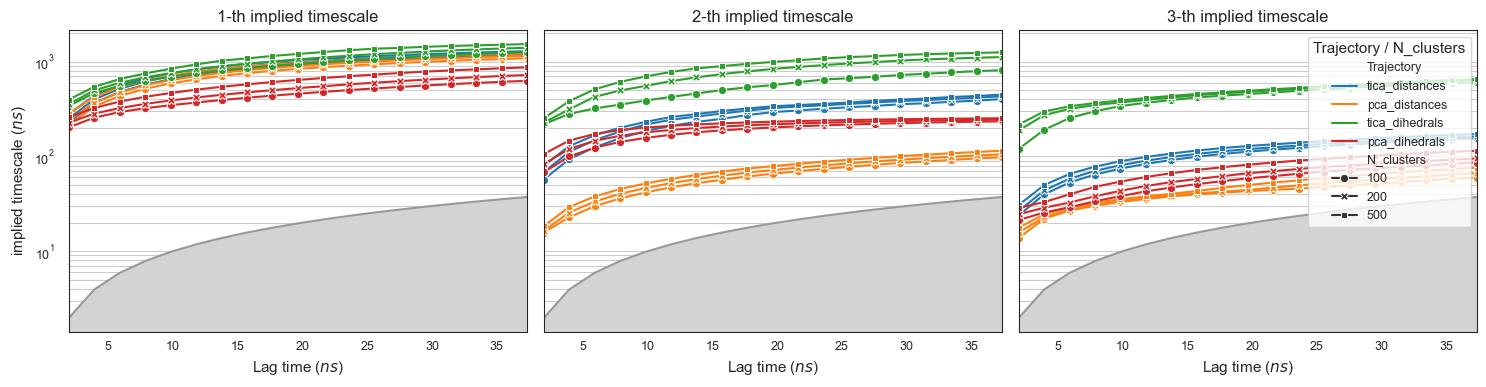

In [25]:
df = pd.read_csv("../intermediate_outputs/implied_timescales.csv", index_col=[0, 1, 2])
df.index.names = ["Trajectory", "N_clusters", "Lag"]


df = df.reset_index().drop_duplicates(subset=["Trajectory", "N_clusters", "Lag"], keep="last").set_index(["Trajectory", "N_clusters", "Lag"])
df = df.reset_index()

# convert times to nanoseconds
df["Lag"] = df["Lag"].astype(float) * time_step_nanos
for col in df.columns:
    if col.startswith("Timescale_"):
        df[col] = df[col].astype(float) * time_step_nanos



sns.set_style("white")
n_timescales_to_plot = 3

fig, axs = plt.subplots(1, n_timescales_to_plot, figsize=(5*n_timescales_to_plot, 4), sharey=True, sharex=True)


vals = np.sort(df["Lag"].unique())
for ax in axs:
    ax.plot(vals, vals, color = "grey", alpha = 0.7) 
    ax.fill_between(vals, -10, vals, color = "lightgrey", alpha = 1) 
    ax.set_yscale("log")
    ax.yaxis.set_major_locator(LogLocator(base=10))
    ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
    ax.tick_params(axis='y', which='minor', length=4)
    ax.tick_params(axis='y', which='major', length=7)
    ax.grid(axis = "y", which = "both", linestyle = "-", linewidth = 0.8)



for i in range(1, n_timescales_to_plot + 1):
    sns.lineplot(data=df, ax = axs[i-1], x="Lag", y=f"Timescale_{i}", hue="Trajectory", style="N_clusters", markers=True, dashes=False)
    axs[i-1].set_xlim(df["Lag"].unique().min(), df["Lag"].unique().max())
    axs[i-1].set_xlabel("Lag time ($ns$)") 
    axs[i-1].set_ylabel(f"implied timescale ($ns$)")
    axs[i-1].set_title(f"{i}-th implied timescale")
    if i != n_timescales_to_plot:
        axs[i-1].get_legend().remove()


axs[n_timescales_to_plot - 1].legend(title="Trajectory / N_clusters", loc = "upper right")
plt.tight_layout()
plt.show()


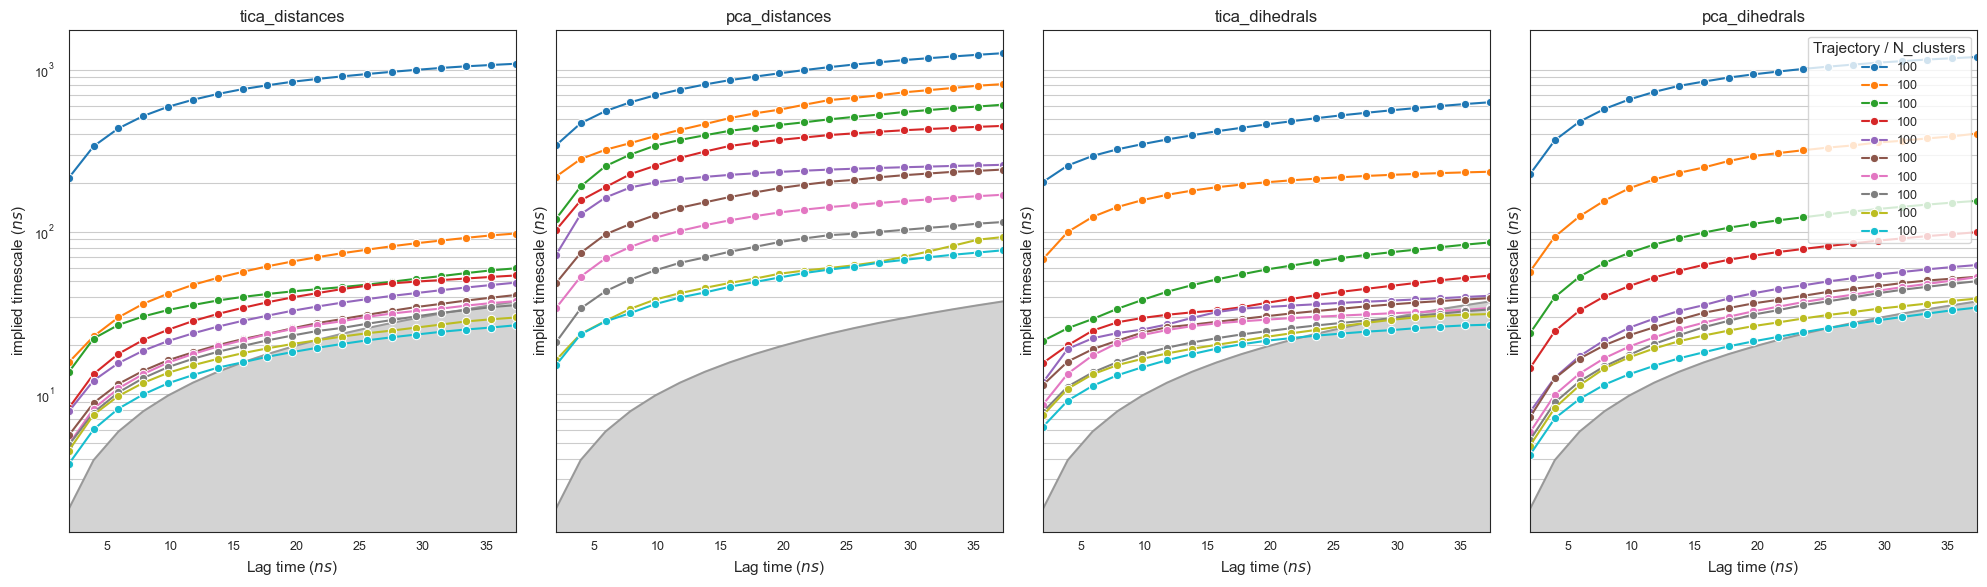

In [26]:
# Plot timescales for trajectories separately

sns.set_style("white")
n_timescales_to_plot = 10
n_clusters_to_plot = 100

fig, axs = plt.subplots(1, 4, figsize=(5*4, 6), sharey=True, sharex=True)


vals = np.sort(df["Lag"].unique())
for ax in axs:
    ax.plot(vals, vals, color = "grey", alpha = 0.7) 
    ax.fill_between(vals, -10, vals, color = "lightgrey", alpha = 1) 
    ax.set_yscale("log")
    ax.yaxis.set_major_locator(LogLocator(base=10))
    ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
    ax.tick_params(axis='y', which='minor', length=4)
    ax.tick_params(axis='y', which='major', length=7)
    ax.grid(axis = "y", which = "both", linestyle = "-", linewidth = 0.8)
    ax.set_xlim(df["Lag"].unique().min(), df["Lag"].unique().max())
    ax.set_xlabel("Lag time ($ns$)") 
    ax.set_ylabel(f"implied timescale ($ns$)")


for i, name in enumerate(trajectories_labels):
    temp = df[(df["Trajectory"] == name) & (df["N_clusters"] == n_clusters_to_plot)]
    for scale in range(1, n_timescales_to_plot + 1):
        sns.lineplot(data=temp, ax = axs[i-1], x="Lag", y=f"Timescale_{scale}", style="N_clusters", markers=True, dashes=False)
    if i != n_timescales_to_plot:
        axs[i-1].get_legend().remove()
    axs[i].set_title(f"{name}")


axs[3].legend(title="Trajectory / N_clusters", loc = "upper right")
plt.tight_layout()
plt.show()

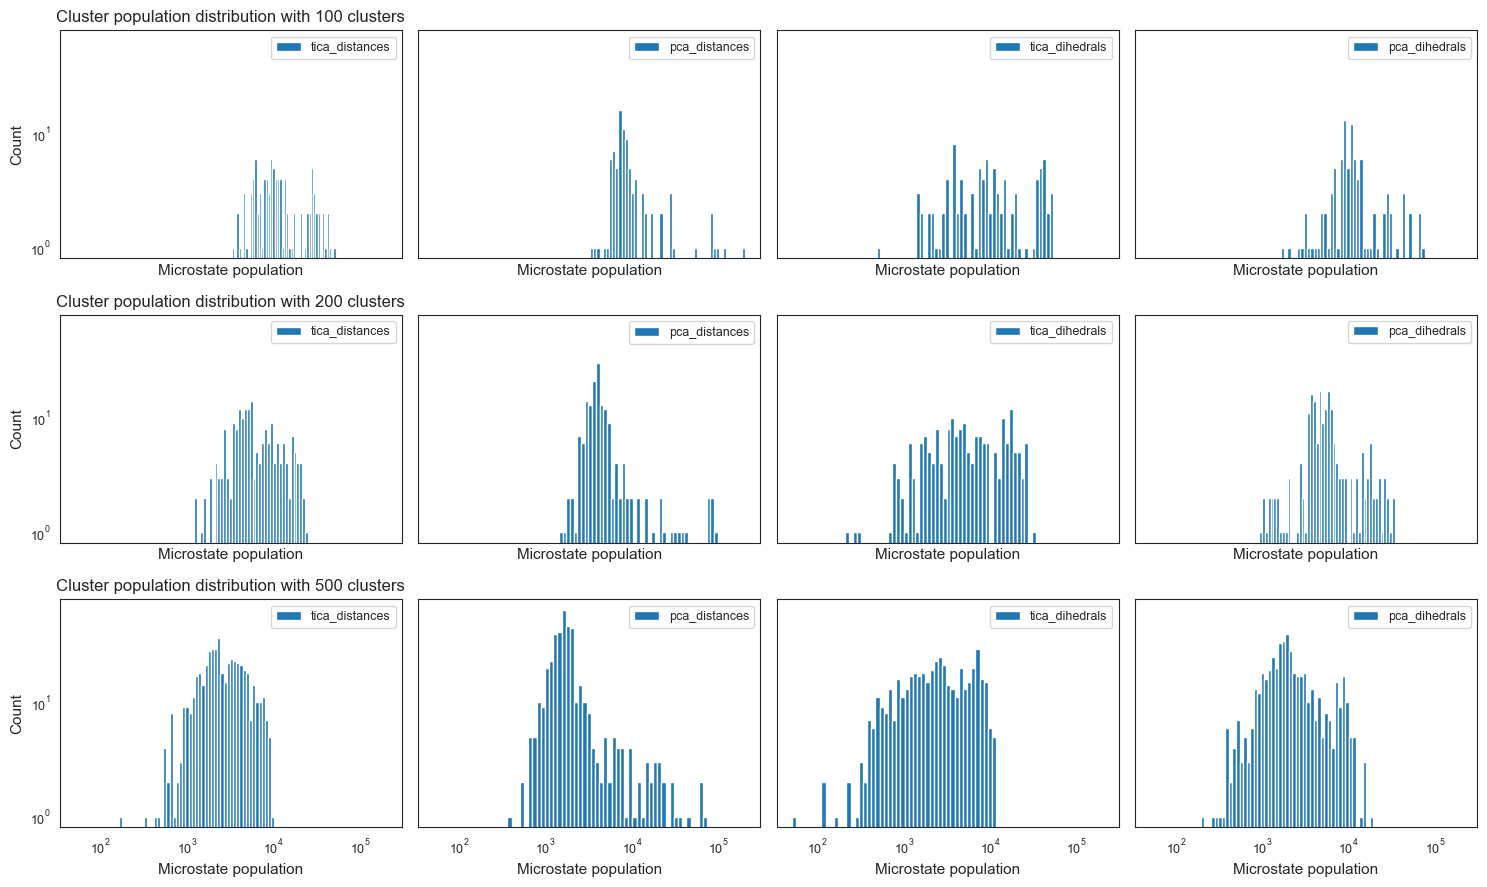

In [27]:
# check cluster populations
fig, axes = plt.subplots(
    len(kcluster_list),
    len(trajectories_labels),
    figsize=(15, 3 * len(kcluster_list)),
    sharex=True,
    sharey=True,
)


for row, n_clusters in enumerate(kcluster_list):
    for col, traj_name in enumerate(trajectories_labels):
        ax = axes[row, col]
        data = np.load(f"../intermediate_outputs/kmeans/{n_clusters}clusters_{traj_name}.npz")
        assignments = data["traj"]
        unique, counts = np.unique(assignments, return_counts=True)
        bins = np.logspace(np.log10(counts.min()),
                np.log10(counts.max()),
                50)

        ax.hist(counts, bins=bins, label=traj_name)
        #axs[i].hist(counts, bins=50, label = traj_name)
        ax.set_xscale("log")
        ax.legend()
        ax.set_yscale("log")
        ax.set_xlabel("Microstate population")
        if col == 0:
                ax.set_ylabel("Count")
                ax.set_title(f"Cluster population distribution with {n_clusters} clusters")

plt.tight_layout()
plt.show()

---
### Estimate MSM at the chosen lagtime $\tau$, and transform cluster-idx trajectories to microstate-idx trajectories

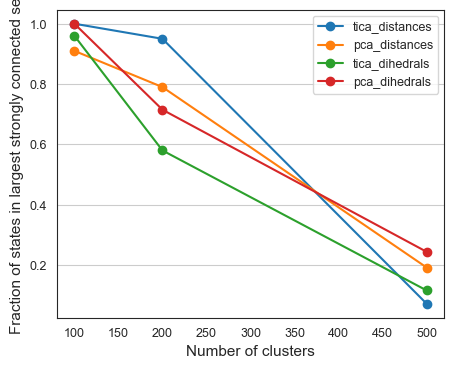

In [28]:
# Inspect largest connected set at varying graph size (number of clusters)

msm_lag = 100 # 20 ns
tce = TransitionCountEstimator(lagtime=msm_lag, count_mode="sliding-effective")
kcluster_list = [100, 200, 500]

sizes = {}

for n_clusters in kcluster_list:
    for i, name in enumerate(trajectories_labels):
        data = np.load(f"../intermediate_outputs/kmeans/{n_clusters}clusters_{name}.npz")
        dtraj = data["traj"].copy()
        C = tce.fit(dtraj).fetch_model()
        submodel = C.submodel_largest(connectivity_threshold=1., directed=True)
        sizes[name, n_clusters] = submodel.n_states/n_clusters

# plot
fig, ax = plt.subplots(figsize=(5, 4))
for name in trajectories_labels:
    x = [n_clusters for (traj_name, n_clusters) in sizes.keys() if traj_name == name]
    y = [sizes[traj_name, n_clusters] for (traj_name, n_clusters) in sizes.keys() if traj_name == name]
    ax.plot(x, y, marker="o", label=name)


ax.set_xlabel("Number of clusters")
ax.set_ylabel("Fraction of states in largest strongly connected set")
ax.legend()
ax.grid(axis = "y", which = "both", linestyle = "-", linewidth = 0.8)
plt.show()

Number of clusters was chosen as $100$ as this gives the largest connected set with respect to the graph size.

In [29]:
msm_lag = 100 # 20 ns
n_clusters = 100
tce = TransitionCountEstimator(lagtime=msm_lag, count_mode="sliding-effective")

msm_dict = {}
cluster_centers_dict = {} # cluster idx to microstate idx
micro_trajectory_dict = {} # traj -> micro traj
clean_micro_trajectory_dict = {} # traj -> micro traj

for i, name in enumerate(trajectories_labels):
    data = np.load(f"../intermediate_outputs/kmeans/{n_clusters}clusters_{name}.npz")
    dtraj = data["traj"].copy()
    C = tce.fit(dtraj).fetch_model()
    submodel = C.submodel_largest(connectivity_threshold=1., directed=True)

    #cluster_centers_dict[name] = submodel.transform_discrete_trajectories_to_submodel(np.arange(n_clusters))
    micro_trajectory_dict[name] = submodel.transform_discrete_trajectories_to_submodel(data["traj"])
    np.save(f"../intermediate_outputs/microstate_trajs/{n_clusters}clusters_{msm_lag}lag_{name}_submodel.npy", micro_trajectory_dict[name])

    clean_micro_trajectory_dict[name] = pu.clean_assignments(micro_trajectory_dict[name], max_dist= 100)

    msm = MaximumLikelihoodMSM(reversible = True).fit(submodel).fetch_model()
    msm_dict[name] = msm

In [30]:
for name, msm in msm_dict.items():
    print("Name: {}, active states: {}".format(name, msm.n_states))
    print("Eigenvalues: ", msm.eigenvalues(k=10))

Name: tica_distances, active states: 100
Eigenvalues:  [1.         0.97922459 0.93533372 0.83946181 0.75959785 0.625631
 0.58210732 0.54588922 0.53022946 0.47381788]
Name: pca_distances, active states: 91
Eigenvalues:  [1.         0.97694565 0.74172712 0.63340288 0.60815843 0.54820855
 0.46250518 0.45881305 0.42560334 0.38177706]
Name: tica_dihedrals, active states: 96
Eigenvalues:  [1.         0.97906103 0.95815697 0.94875957 0.91973461 0.90075367
 0.86231784 0.79726332 0.70098527 0.68758892]
Name: pca_dihedrals, active states: 100
Eigenvalues:  [1.         0.95817746 0.90746431 0.71559947 0.58422875 0.56552024
 0.52251694 0.50561845 0.44761441 0.41883052]


#### Visualization of the free energy $-\ln{\pi}$

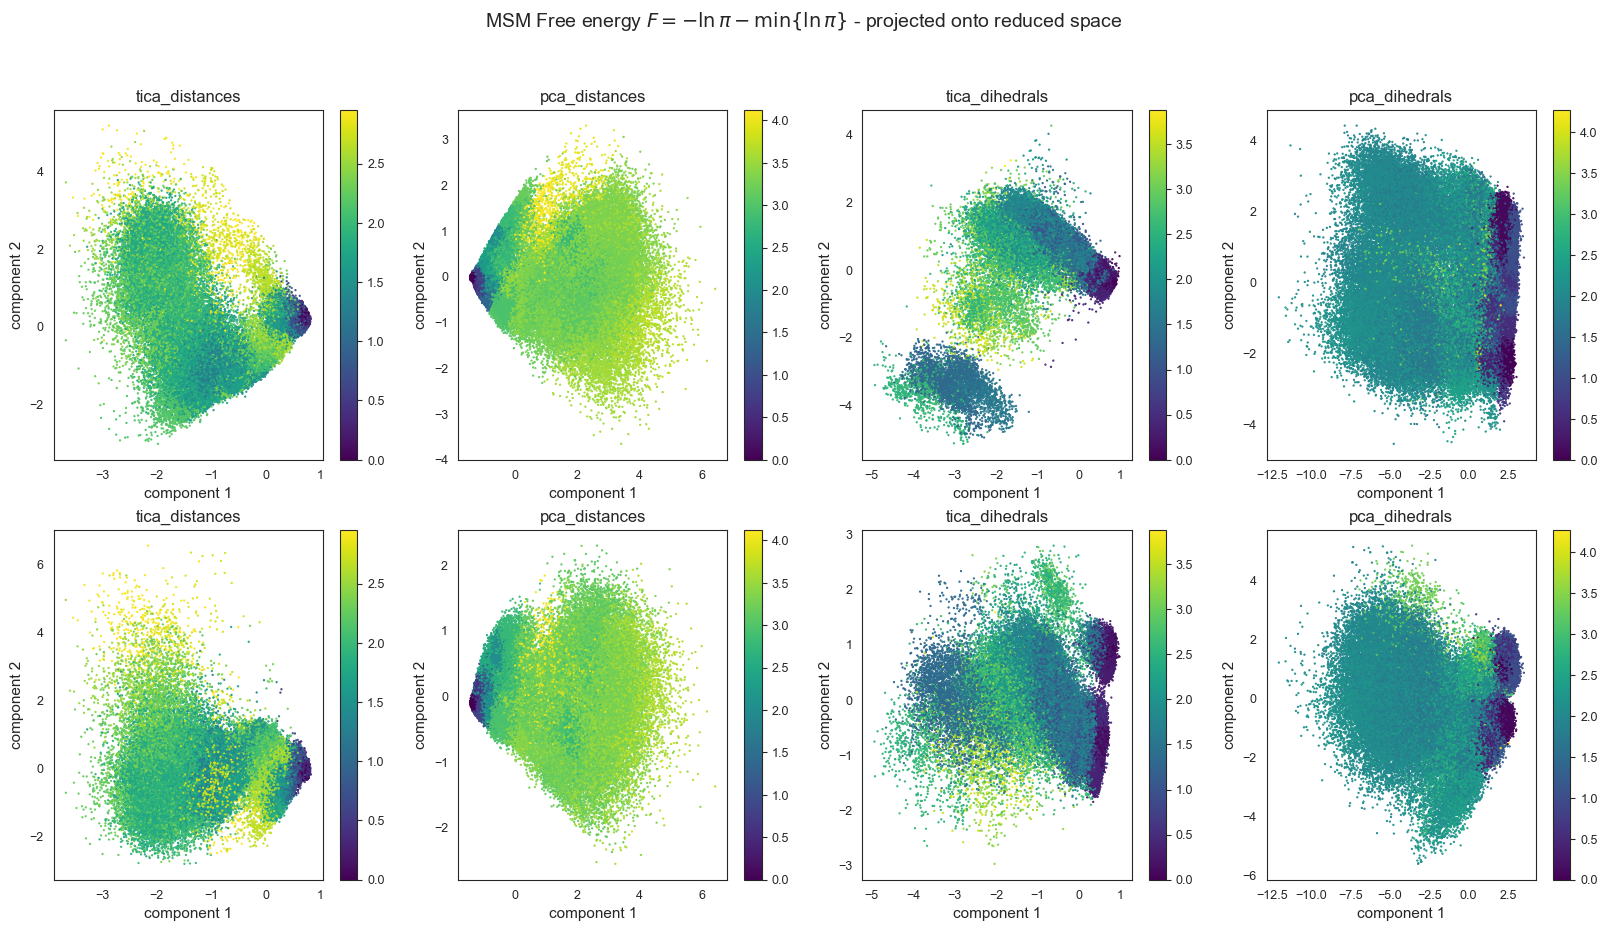

In [31]:
fig, axs = plt.subplots(nrows = 2, ncols = 4, figsize=(20, 10))


for i, name in enumerate(trajectories_labels):

    traj = micro_trajectory_dict[name]
    pi = msm_dict[name].stationary_distribution

    # transform  to free energy
    F = np.full_like(pi, np.nan)
    mask = pi > 0
    F[mask] = -np.log(pi[mask])
    F -= np.nanmin(F)

    z_values = np.full(len(traj), np.nan)
    mask = traj != -1
    z_values[mask] = F[traj[mask]]



    ax = axs[0, i]
    ax.scatter(trajectories[i][:, 0][::10], trajectories[i][:, 1][::10], c = z_values[::10], cmap = "viridis", s=0.4, alpha=1)
    plt.colorbar(ax.collections[0], ax=ax)
    ax.set_xlabel("component 1")
    ax.set_ylabel("component 2")
    ax.set_title(f"{name}")


    ax = axs[1, i]
    ax.scatter(trajectories[i][:, 0][::10], trajectories[i][:, 3][::10], c = z_values[::10], cmap = "viridis", s=0.4, alpha=1)
    plt.colorbar(ax.collections[0], ax=ax)
    ax.set_xlabel("component 1")
    ax.set_ylabel("component 2")
    ax.set_title(f"{name}")


plt.suptitle(r"MSM Free energy $F = -\ln{\pi} - \min\{{\ln{\pi}}\}$ - projected onto reduced space")   
plt.show()

---
###  Validation of the microstate model: autocorrelation test (RMSD)

Lets call $\theta (\vec{x})$ an observable of the molecular trajectory.
- Construct the vector of observables $\mathbf{\theta} = (\theta_1, \, \theta_N)$ containing the value of the observable $\theta$ in each markov microstate.


    0. For each cluster center, I take the state closest to the cluster center as the representative state of the markov microstate;
    1. For each representative state, extract its temporal frame index and use it to retrieve the corresponding value of the RMSD from the crystal structure.

- Compute the model predicted autocorrelation according to:

$$
ACF_\theta(k) = \frac{\sum_{i=1}^{N}\, \lambda_i^k\, \langle\mathbf{\theta}, \mathbf{r_i} \rangle^2}{\sum_{i=1}^{N}\, \langle\mathbf{\theta}, \mathbf{r_i}\rangle^2}
$$

where the $\mathbf{r}_i$ are the right eigenvectors of the transition matrix.

- Compare with the empirical autocorrelation.

In [32]:
from scipy.signal import correlate
from deeptime.markov.tools.analysis import correlation


def get_empirical_autocorrelation(obs):
    obs = obs - obs.mean()
    acf = correlate(obs, obs, mode="full")
    acf = acf[acf.size // 2:]      # keep non-negative lags
    acf /= acf[0]                  # normalize so acf[0] = 1
    return acf


def get_msm_autocorrelation(obs, msm, times_array):
    """
    obs: array of observables, one for each microstate
    msm: object of the class deeptime::MarkovStateModelCollection
    """
    # center the observable using the stationary distribution
    obs_mean = np.dot(msm.stationary_distribution, obs)
    obs = obs - obs_mean
    variance = correlation(T = msm.transition_matrix, 
                                obs1 = obs, 
                                obs2=None, 
                                times=(0,), 
                                k=None, 
                                ncv=None)[0]
    
    times_array_in_units_of_tau = np.array(times_array / msm.lagtime, dtype = int)
    acf = correlation(T = msm.transition_matrix, 
                                obs1 = obs, 
                                obs2=None, 
                                times=times_array_in_units_of_tau, 
                                k=None, 
                                ncv=None)
    
    return acf/variance



RMSD_timeseries = np.load("../intermediate_outputs/RMSD_crystal_nm.npy")

theta_dict = {} # one array of observables per each msm model

for i, name in enumerate(trajectories_labels):
    traj = micro_trajectory_dict[name]
    msm = msm_dict[name]
    theta_array = np.ones(msm.n_states)  * (-1)
    for j in np.arange(0, msm.n_states):
        representative_frames = np.where(traj == j)[0]
        RMSD_values = RMSD_timeseries[representative_frames]
        theta_array[j] = np.mean(RMSD_values)
    theta_dict[name] = theta_array


empirical_acf = get_empirical_autocorrelation(RMSD_timeseries)



max_time = 100000 # in frames, corresponds to 20 microseconds
print("Max time for ACF (frames)", max_time)
print("Max time for ACF (nanoseconds)", max_time * time_step_nanos) # 20 microseconds
model_acf_dict = {}
for name in trajectories_labels:
    theta_array = theta_dict[name]
    model_acf_dict[name] = get_msm_autocorrelation(theta_dict[name], msm_dict[name], times_array=np.arange(0, max_time)) 

Max time for ACF (frames) 100000
Max time for ACF (nanoseconds) 19658.711659778473


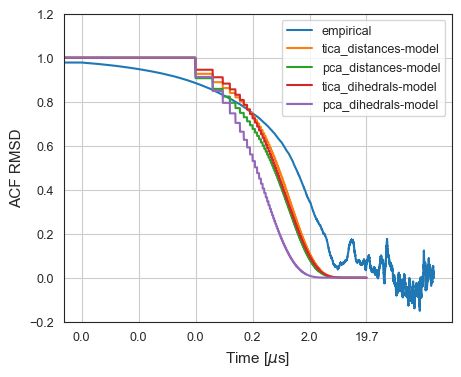

In [33]:
fig, ax = plt.subplots(figsize = (5,4))


ax.plot(np.arange(len(empirical_acf)), empirical_acf, label = "empirical")
for name in trajectories_labels:
    model_acf = model_acf_dict[name]
    ax.plot(np.arange(len(model_acf)), model_acf, label = f"{name}-model")

ax.set_xscale("log", base=10)
# ticks at powers of 10 frames
xticks = [1, 10, 100, 1000, 10000, 100000]
xticks = [x for x in xticks if x < len(empirical_acf)]
ax.set_xticks(xticks)
ax.set_xticklabels([f"{x*time_step_micros:.1f}" for x in xticks])

ax.legend()
ax.set_ylabel("ACF RMSD")
ax.set_xlabel(f"Time [$\mu$s]")
ax.grid()
plt.ylim(-0.2, 1.2)
plt.show()

Seems quite good, but without error bars what can you say?

TODO:
- look into Bayesian MSMs
- optionally consider bootstrapping.

---
---

## Spectral analysis of the microstate model

In [ ]:
# eigenvalues plot
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(16, 4), sharey=True, sharex=True)
axs = axs.flatten()

for i, name in enumerate(trajectories_labels):
    msm = msm_dict[name]
    eigvals = msm.eigenvalues(k=20)
    ax = axs[i]
    ax.plot(np.arange(20), eigvals, marker="o", label=name)

    ax.set_xticks(np.arange(0, 20, 2))
    ax.set_xticklabels(1 + np.arange(0,20, 2))
    ax.set_xlabel("Eigenvalue index $i$")

    if i == 0:
        ax.set_ylabel("Eigenvalue $\lambda_i$")

    ax.legend(title="")
    ax.grid(which="both", axis="y", linestyle="-", linewidth=0.8)

plt.tight_layout()
plt.show()

In [ ]:
# Timescales plot
################ CHOICE OF THE THRESHOLD FOR TIMESCALES

print(f"Markov chain lag: {msm_lag * time_step_nanos:.2f} ns ({msm_lag} frames)")

threshold_ns = 50
threshold_frames = int(threshold_ns / time_step_nanos)

print(f"Threshold for timescales: {threshold_ns:.2f} ns ({threshold_frames} frames)")

n_macrostates_dict = {}

fig, axs = plt.subplots(
    nrows=1, ncols=4,
    figsize=(16, 4),
    sharey=True,
    sharex=True
)
axs = axs.flatten()

for i, name in enumerate(trajectories_labels):
    msm = msm_dict[name]
    timescales_ns = msm.timescales(k=20) * time_step_nanos
    indices = np.arange(1, len(timescales_ns) + 1)
    n_macrostates_dict[name] = np.sum(timescales_ns > threshold_ns) + 1


    ax = axs[i]
    ax.plot(indices, timescales_ns, marker="o", label=name)

    ax.axhline(
        y=msm_lag * time_step_nanos,
        color="grey",
        label="MSM lag"
    )

    ax.fill_between(
        indices,
        0,
        msm_lag * time_step_nanos,
        color="grey",
        alpha=0.2,
        label="unresolved region"
    )
    ax.axhline(
        y=threshold_ns,
        color="red",
        linestyle="--",
        label="threshold"
    )

    ax.set_xticks(indices[::4])
    ax.set_xlabel("Timescale index")

    if i == 0:
        ax.set_ylabel("Timescale [ns]")

    ax.legend(title="Implied timescales")
    ax.grid(which="both", axis="y", linestyle="-", linewidth=0.8)

plt.tight_layout()


plt.tight_layout()
plt.show()
print("Number of macrostates for PCCA (number oftimescales above threshold, plus 1):")
for name, n_macrostates in n_macrostates_dict.items():
    print(f"  {name}: {n_macrostates}")


In [ ]:
# Plot 1-Q for reference, and msm leading three eigenvectors
# (row stochastic convention -> look at the *right* eigenvectors)

RMSD_timeseries = np.load("../intermediate_outputs/RMSD_crystal_nm.npy")
z_timeseries = RMSD_timeseries - RMSD_timeseries.min()
z_timeseries = z_timeseries / z_timeseries.max() # now ranges from 0 to 1

fig, axs = plt.subplots(nrows = 1, ncols = 4, figsize=(20, 5))

for i, name in enumerate(trajectories_labels):
    ax = axs[i]
    ax.scatter(trajectories[i][:, 0][::10], trajectories[i][:, 1][::10], c = z_timeseries[::10], cmap = "RdBu_r", s=0.4, alpha=1)
    if i == len(trajectories_labels) - 1:
        plt.colorbar(ax.collections[0], ax=ax, label="RMSD (normalized)")
    #else:
    #    plt.colorbar(ax.collections[0], ax=ax)
    ax.set_xlabel("component 1")
    ax.set_ylabel("component 2")
    ax.set_title(f"{name}")

plt.suptitle(r"RMSD to crystal structure - projected onto reduced space")     
plt.show()

In [ ]:
Q_timeseries = np.load("../intermediate_outputs/Q_timeseries_all.npy")


fig, axs = plt.subplots(nrows = 1, ncols = 4, figsize=(20, 5))

for i, name in enumerate(trajectories_labels):
    ax = axs[i]
    ax.scatter(trajectories[i][:, 0][::10], trajectories[i][:, 1][::10], c = Q_timeseries[::10], cmap = "RdBu_r", s=0.4, alpha=1)
    if i == len(trajectories_labels) - 1:
        plt.colorbar(ax.collections[0], ax=ax, label="Fraction of native contacts")
    #else:
        #plt.colorbar(ax.collections[0], ax=ax)
    ax.set_xlabel("component 1")
    ax.set_ylabel("component 2")
    ax.set_title(f"{name}")

plt.suptitle(r"Fraction of native contacts Q - projected onto reduced space")     
plt.show()

In [ ]:
# Plotting the first three eigenvectors of the MSMs
eigvecs_to_plot = 1

fig, axs = plt.subplots(
    nrows=eigvecs_to_plot,
    ncols=4,
    figsize=(20, 5 * eigvecs_to_plot),
    squeeze=False,  # always return a 2D array
)


for i, name in enumerate(trajectories_labels):
    msm = msm_dict[name]
    #R = msm.eigenvectors_right(k=eigvecs_to_plot + 1)[:, 1:] # skip the first one which is np.ones

    L = msm.eigenvectors_left(k=eigvecs_to_plot+1)[1:, :].T # includes the first one which is np.ones, but we will plot it as well for reference
    # renormalize each eigenvector to range approximately from -1 to 1 for better visualization
    #R_normalized = R / np.abs(R).max(axis=0)
    L_normalized = L / np.abs(L).max(axis=0)


    traj = micro_trajectory_dict[name]
    # transform  to eigvec values
    z_values = np.full((len(traj), eigvecs_to_plot), np.nan)
    mask = traj != -1
    #z_values[mask] = R_normalized[traj[mask], :eigvecs_to_plot]
    z_values[mask] = L_normalized[traj[mask], :eigvecs_to_plot]

    xy = trajectories[i]

    for row in range(eigvecs_to_plot):
        ax = axs[row, i]
        #ax = axs[i]
        norm = TwoSlopeNorm(vcenter=0.0)
        
        ax.scatter(xy[:, 0][::10], xy[:, 1][::10], c = z_values[::10, row], norm = norm, cmap = "PiYG", s=0.4, alpha=1)
        if i == len(trajectories_labels) - 1:
            plt.colorbar(ax.collections[0], ax=ax, label=f"Eigenvector {row+1} value")
        else:
            plt.colorbar(ax.collections[0], ax=ax)
        ax.set_xlabel("component 1")
        ax.set_ylabel("component 2")
        ax.set_title(f"{name}")    

The first relaxation process is clearly  the folding<->unfolding. This is robust across the different methods.

For the subsequent ones, it is not so clear what they represent. For contacts, they *may* correspond to making and breaking of particular subsets of contacts, and thus be tightly related to the folding process. However, in the dihedral representation it is even less clear what these relaxation processes are. They might as well correspond to the rigid rotation of some part of the protein with respect to the other.




If we want to compute a mean first passage time we should first identify a suitable set of source and target states. If we just want folded<->unfolded, we might use a threshold on the contact formation (like, folded if Q > 0.95 and unfolded if Q < 0.1) and compute committor.


This could be a reasonable first step actually. If the committor is a sharp step like function, there is no point in going forward: two state model is all we have. 




Next we inspect 

---
---

# Coarse graining
#### Macrostate MSM: lagtime choice and CK validation


[From book, ch 2.5] 

**Choice of the algorithm**

- The standard approach is PCCA+. PCCA (without the +) is excellently explained in the book. 
- authors of HP35 references suggest instead:
    - Starting with the above-defined microstates, MPP first calculates the transition matrix of these states, using a lag time τMPP = 10 ns. (The choice of τMPP is explained in the discussion of Figure 7a below.)
    -  If the self- transition probability of a given state is lower than a certain metastability criterion Qmin ∈ (0, 1), the state will be lumped with the state to which the transition probability is the highest. 
    - This procedure is reiterated, until there are no more transitions for a given Qmin."


Let's start from PCCA+.


how to handle the -1 frames? For now I simply assign the closest index in time...

In [ ]:
CUSTOM_n_macrostates_dict = {
    "tica_distances": 4,
    "pca_distances": 4,
    "tica_dihedrals": 4,
    "pca_dihedrals": 4
}

In [ ]:
traj_pcca_assignments_dict = {}
for name in trajectories_labels:
    msm = msm_dict[name]
    n_macro = CUSTOM_n_macrostates_dict[name]
    pcca = msm.pcca(n_macro) # compute PCCA++ memberships
    micro_assignments = pcca.assignments  # get the microstate to macrostate assignments (crisp)
    print(f"name: {name}, PCCA probabilities: ", pcca.coarse_grained_stationary_probability)
    # load microstate timeseries
    traj = clean_micro_trajectory_dict[name]

    traj_pcca_assignments = np.array([micro_assignments[s] for s in traj])
    print(traj_pcca_assignments.shape)
    
    traj_pcca_assignments_dict[name] = traj_pcca_assignments
    np.save(f"../intermediate_outputs/pcca/{n_macro}macro_{name}_assignments.npy", traj_pcca_assignments)

---